# Urban Heat & Cooling-Priority Mapping — Heat-Variant Diagnostic

**NUS-ISS Practice Module, Week 2.** Investigates why `lst_bicubic10` showed
a *lower* RMSE against held-out NEA data than `lst_native30`/`lst_regress10`
in `rank_impact.ipynb` — a counterintuitive result for a "dumb" interpolation
baseline. Distinguishes two explanations:

- **A uniform offset** (bicubic10 runs a roughly constant amount cooler
  everywhere) — explainable, not concerning, doesn't undermine the variant.
- **Heat-dependent smoothing** (the gap grows specifically at hot/built-up
  subzones) — would mean cubic interpolation is eating your hottest signal,
  which is a bad property for a heat-priority tool specifically.

One notebook, run top to bottom:

1. **Setup** — install deps, mount Drive
2. **D.1** — config
3. **D.2** — load + descriptive stats per variant
4. **D.3** — pairwise differences (native30 − bicubic10, native30 − regress10)
5. **D.4** — is the gap uniform or heat-dependent? (correlation + regression)
6. **D.5** — plots
7. **D.6** — verdict
8. **D.7** — save plots to Drive

Run cells in order.

---


# SETUP — run once per session

## Setup 1 — Install dependencies

In [1]:
# --- SETUP CELL 1: Install all dependencies used in this notebook ----------
!pip install -q pandas matplotlib scipy


## Setup 2 — Mount Google Drive

In [2]:
# --- SETUP CELL 2: Mount Google Drive ----------------------------------------
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted at /content/drive")


Mounted at /content/drive
Drive mounted at /content/drive


---
# D — Heat-Variant Diagnostic


## D.1 — Config

In [3]:
# --- D CELL 1: Config ---------------------------------------------------------
EXPORT_FOLDER = "urban_heat_sg"
HEAT_CSV_PATH = f"/content/drive/MyDrive/{EXPORT_FOLDER}/heat_variants_subzone.csv"
PLOT_DIR = f"/content/drive/MyDrive/{EXPORT_FOLDER}/diagnostics"

import os
os.makedirs(PLOT_DIR, exist_ok=True)

if not os.path.exists(HEAT_CSV_PATH):
    raise FileNotFoundError(f"{HEAT_CSV_PATH} not found. Run gee_heat_variants.ipynb's export first.")
print("✅ Heat-variants CSV found.")


✅ Heat-variants CSV found.


## D.2 — Load + descriptive stats per variant

In [4]:
# --- D CELL 2: Load + descriptive stats --------------------------------------
import pandas as pd

df = pd.read_csv(HEAT_CSV_PATH)
variants = ["lst_native30", "lst_bicubic10", "lst_regress10"]
missing = set(variants) - set(df.columns)
if missing:
    raise ValueError(f"Missing columns: {missing}")

print(f"Subzones: {len(df)}\n")
print(df[variants].describe().to_string())


Subzones: 332

       lst_native30  lst_bicubic10  lst_regress10
count    332.000000     332.000000     332.000000
mean      39.749212      39.748944      39.751056
std        2.488467       2.488945       2.486896
min       32.077425      32.078449      32.083551
25%       38.454470      38.454837      38.459670
50%       39.935342      39.934212      39.937085
75%       41.254446      41.257664      41.236066
max       46.620987      46.621751      46.623171


## D.3 — Pairwise differences

In [5]:
# --- D CELL 3: Pairwise differences -------------------------------------------
df["diff_bicubic"] = df["lst_native30"] - df["lst_bicubic10"]
df["diff_regress"] = df["lst_native30"] - df["lst_regress10"]

print("native30 - bicubic10 (positive = bicubic reads cooler):")
print(df["diff_bicubic"].describe().to_string())
print(f"\nCoefficient of variation (std/|mean|): {df['diff_bicubic'].std() / abs(df['diff_bicubic'].mean()):.3f}")
print("  Low (<<1) suggests a roughly UNIFORM offset. High (>1 or mean near 0) suggests")
print("  the gap varies a lot subzone-to-subzone, not a simple constant shift.")

print("\n\nnative30 - regress10 (sanity check, should be tiny given mass-conservation correction):")
print(df["diff_regress"].describe().to_string())


native30 - bicubic10 (positive = bicubic reads cooler):
count    332.000000
mean       0.000268
std        0.004457
min       -0.007765
25%       -0.001197
50%       -0.000116
75%        0.000715
max        0.051611

Coefficient of variation (std/|mean|): 16.636
  Low (<<1) suggests a roughly UNIFORM offset. High (>1 or mean near 0) suggests
  the gap varies a lot subzone-to-subzone, not a simple constant shift.


native30 - regress10 (sanity check, should be tiny given mass-conservation correction):
count    332.000000
mean      -0.001844
std        0.018726
min       -0.077174
25%       -0.005795
50%       -0.000898
75%        0.003007
max        0.193232


## D.4 — Is the gap uniform or heat-dependent?

Correlates the (native30 − bicubic10) gap against native30's own value. A
strong positive correlation means the gap is *larger where native30 is
hotter* — i.e. bicubic10 is specifically flattening peak heat, not applying
a constant offset. That's the smoking gun for the interpolation-smoothing
hypothesis.


In [6]:
# --- D CELL 4: Correlation of gap vs heat level -------------------------------
from scipy.stats import pearsonr, linregress

r, p = pearsonr(df["lst_native30"], df["diff_bicubic"])
slope, intercept, r_value, p_value, std_err = linregress(df["lst_native30"], df["diff_bicubic"])

print(f"Pearson correlation (native30 value vs diff_bicubic gap): r = {r:.3f}, p = {p:.4f}")
print(f"Linear fit: diff_bicubic ≈ {slope:.3f} * lst_native30 + {intercept:.3f}  (R² = {r_value**2:.3f})")
print()
if r > 0.4 and p < 0.05:
    print("⚠️  Positive correlation: the native30-bicubic10 gap GROWS at hotter subzones.")
    print("   Consistent with cubic interpolation smoothing/undershooting peak heat —")
    print("   bicubic10's lower RMSE may reflect coincidental smoothing toward air-temp")
    print("   range at hot spots, not genuine accuracy. Worth treating with caution")
    print("   specifically for a HEAT-PRIORITY tool, where peak values matter most.")
elif abs(r) <= 0.4:
    print("✅ Weak/no correlation: the gap looks closer to a roughly uniform offset across")
    print("   subzones regardless of heat level — less concerning, more like a systematic")
    print("   shift than heat-dependent signal loss. Still worth understanding WHY the")
    print("   offset exists, but it doesn't specifically undermine the hottest, highest-priority")
    print("   subzones more than others.")
else:
    print("Negative correlation — gap shrinks at hotter subzones. Unexpected; inspect further.")


Pearson correlation (native30 value vs diff_bicubic gap): r = -0.106, p = 0.0531
Linear fit: diff_bicubic ≈ -0.000 * lst_native30 + 0.008  (R² = 0.011)

✅ Weak/no correlation: the gap looks closer to a roughly uniform offset across
   subzones regardless of heat level — less concerning, more like a systematic
   shift than heat-dependent signal loss. Still worth understanding WHY the
   offset exists, but it doesn't specifically undermine the hottest, highest-priority
   subzones more than others.


## D.5 — Plots

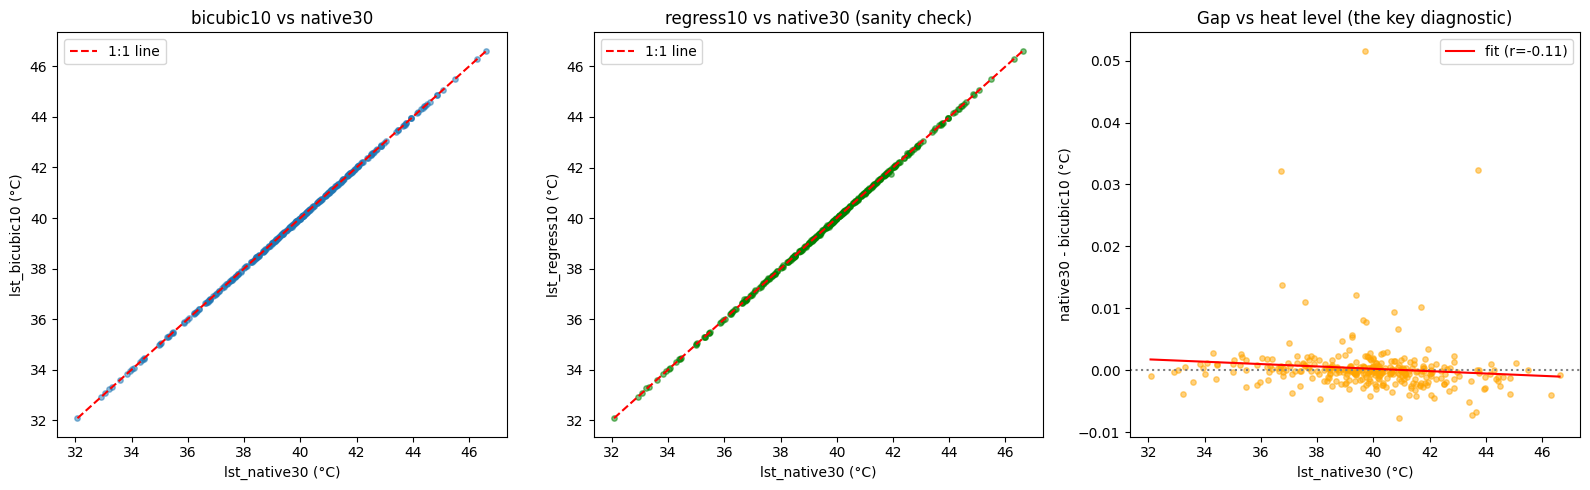

In [7]:
# --- D CELL 5: Plots -----------------------------------------------------------
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: bicubic10 vs native30, with 1:1 line
ax = axes[0]
ax.scatter(df["lst_native30"], df["lst_bicubic10"], alpha=0.5, s=15)
lims = [df[["lst_native30", "lst_bicubic10"]].min().min(), df[["lst_native30", "lst_bicubic10"]].max().max()]
ax.plot(lims, lims, "r--", label="1:1 line")
ax.set_xlabel("lst_native30 (°C)")
ax.set_ylabel("lst_bicubic10 (°C)")
ax.set_title("bicubic10 vs native30")
ax.legend()

# Plot 2: regress10 vs native30, with 1:1 line (sanity check — should hug the line)
ax = axes[1]
ax.scatter(df["lst_native30"], df["lst_regress10"], alpha=0.5, s=15, color="green")
lims2 = [df[["lst_native30", "lst_regress10"]].min().min(), df[["lst_native30", "lst_regress10"]].max().max()]
ax.plot(lims2, lims2, "r--", label="1:1 line")
ax.set_xlabel("lst_native30 (°C)")
ax.set_ylabel("lst_regress10 (°C)")
ax.set_title("regress10 vs native30 (sanity check)")
ax.legend()

# Plot 3: the diagnostic — diff_bicubic vs native30 value
ax = axes[2]
ax.scatter(df["lst_native30"], df["diff_bicubic"], alpha=0.5, s=15, color="orange")
ax.axhline(0, color="gray", linestyle=":")
fit_x = [df["lst_native30"].min(), df["lst_native30"].max()]
fit_y = [slope * x + intercept for x in fit_x]
ax.plot(fit_x, fit_y, "r-", label=f"fit (r={r:.2f})")
ax.set_xlabel("lst_native30 (°C)")
ax.set_ylabel("native30 - bicubic10 (°C)")
ax.set_title("Gap vs heat level (the key diagnostic)")
ax.legend()

plt.tight_layout()
plt.show()


## D.6 — Verdict

In [8]:
# --- D CELL 6: Verdict ---------------------------------------------------------
print("\n--- D Verdict ---")
print(f"Mean gap (native30 - bicubic10): {df['diff_bicubic'].mean():.2f} °C")
print(f"Std of gap: {df['diff_bicubic'].std():.2f} °C")
print(f"Correlation of gap with heat level: r = {r:.3f}")
print()
if r > 0.4 and p < 0.05:
    print("⚠️  Recommend treating bicubic10's lower held-out RMSE with caution in your")
    print("   write-up — flag the heat-dependent gap explicitly rather than reporting")
    print("   'bicubic10 is more accurate' at face value.")
else:
    print("✅ Gap looks closer to a uniform offset. Still worth a one-line note on WHY")
    print("   (e.g. interpolation kernel, or a genuine averaging effect), but less likely")
    print("   to be selectively erasing your highest-priority hot subzones.")



--- D Verdict ---
Mean gap (native30 - bicubic10): 0.00 °C
Std of gap: 0.00 °C
Correlation of gap with heat level: r = -0.106

✅ Gap looks closer to a uniform offset. Still worth a one-line note on WHY
   (e.g. interpolation kernel, or a genuine averaging effect), but less likely
   to be selectively erasing your highest-priority hot subzones.


## D.7 — Save plots to Drive

In [9]:
# --- D CELL 7: Save plots to Drive ----------------------------------------------
out_path = f"{PLOT_DIR}/heat_variant_diagnostic.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved: {out_path}")


Saved: /content/drive/MyDrive/urban_heat_sg/diagnostics/heat_variant_diagnostic.png
